# Kalibrasi Skenario Hybrid NLP Tanpa LLM
Notebook ini menjadi alur presentasi. Logic utama tetap berada di folder `services/` agar mudah dipindahkan ke `main.py`.


In [1]:
from pathlib import Path
import sys

import polars as pl
from IPython.display import display


def find_project_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in (current, *current.parents):
        if (candidate / "config.py").exists() and (candidate / "services").is_dir():
            return candidate
    raise FileNotFoundError("Root proyek tidak ditemukan")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import config
from services.ambiguity_service import AmbiguityService
from services.artifact_service import ArtifactService
from services.clustering_service import ClusteringService
from services.dataset_service import DatasetService
from services.embedding_service import EmbeddingService
from services.evaluation_service import EvaluationService
from services.lexicon_sentiment_service import LexiconSentimentService
from services.preprocessing_service import PreprocessingService
from services.visualization_service import VisualizationService

pl.Config.set_tbl_hide_column_data_types(True)
pl.Config.set_tbl_cell_alignment("LEFT")
pl.Config.set_tbl_width_chars(10_000)
pl.Config.set_tbl_cols(-1)
pl.Config.set_tbl_rows(20)


polars.config.Config

## 1. Konfigurasi Dataset


In [2]:
DATASET_PATH = config.DATASETS / "raw_candidate_schema.csv"
OUTPUT_DATASET_PATH = config.CALIBRATION_DATASET_PATH
OUTPUT_SUMMARY_PATH = config.CALIBRATION_SUMMARY_PATH
OUTPUT_RESULTS_PATH = config.NON_LLM_RESULTS_PATH
OUTPUT_METRICS_PATH = config.NON_LLM_METRICS_PATH

RANDOM_SEED = 42
SOURCE_NAME = "tokopedia"
MAX_ROWS = 2_000  # ubah ke None jika ingin menjalankan seluruh dataset

print(f"Dataset: {DATASET_PATH}")
print(f"Batas baris demo: {MAX_ROWS if MAX_ROWS else 'semua'}")

Dataset: E:\School\tugas-akhir\project\datasets\raw_candidate_schema.csv
Batas baris demo: 2000


## 2. Load, Adaptasi Kolom, Validasi


Baris sumber: 855
Baris digunakan: 855
{'total_rows': 855, 'required_columns': ['id', 'source', 'text'], 'missing_columns': [], 'null_text': 0, 'empty_text': 0, 'empty_source': 0, 'is_valid': True, 'issues': []}


{'total_data': 855,
 'distribusi_sumber': {'tokopedia': 855},
 'jumlah_data_kosong': 0,
 'jumlah_duplikat': 1,
 'rata_rata_panjang_teks': 3810.25}

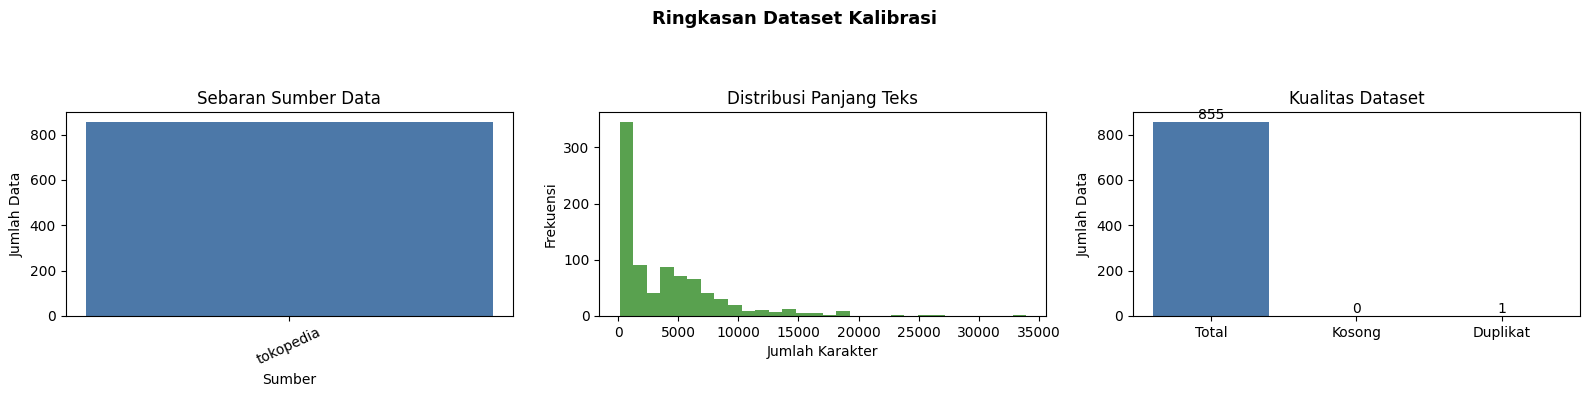

In [3]:
dataset_service = DatasetService()
evaluation_service = EvaluationService()
artifact_service = ArtifactService()
visualization_service = VisualizationService()

raw_df = dataset_service.load(DATASET_PATH)
if config.COL_TEXT not in raw_df.columns:
    raise KeyError(f"Kolom '{config.COL_TEXT}' tidak ditemukan pada dataset")

base_df = raw_df
if MAX_ROWS is not None:
    base_df = base_df.head(MAX_ROWS)

text_df = (
    base_df.select(config.COL_TEXT)
    .with_row_index(config.COL_ID, offset=1)
    .with_columns(
        pl.col(config.COL_ID).cast(pl.Utf8),
        pl.lit(SOURCE_NAME).alias(config.COL_SOURCE),
        pl.col(config.COL_TEXT).cast(pl.Utf8, strict=False),
    )
    .select(
        config.COL_ID,
        config.COL_SOURCE,
        config.COL_TEXT,
    )
)

validation = dataset_service.validate(text_df)
summary = dataset_service.build_summary(text_df)

print(f"Baris sumber: {raw_df.height:,}")
print(f"Baris digunakan: {text_df.height:,}")
print(validation)
display(summary)
fig_dataset = visualization_service.plot_dataset_overview(text_df, summary)

## 3. Cleaning, Deduplikasi, dan Preprocessing


Baris setelah preprocessing: 854


id,text,processed_text
"""1""","""Program Listrik Desa di Papua …","""program listrik desa di papua …"
"""2""","""Ari Yunianto on Instagram: ""Be…","""ari yunianto on instagram beka…"
"""3""","""OIS POWER on Instagram: ""#PLTS…","""ois power on instagram pembang…"
"""4""","""TEKNIK LISTRIK on Instagram: ""…","""teknik listrik on instagram pa…"
"""5""","""Datascrip Service Center on In…","""datascrip service center on in…"
"""6""","""TikTok - Make Your Day Listrik…","""tiktok - make your day listrik…"
"""7""","""Damai Cable Indonesia on Insta…","""damai cable indonesia on insta…"
"""8""","""TikTok - Make Your Day Teknolo…","""tiktok - make your day teknolo…"
"""9""","""Wujud Negara Hadir, Pemerintah…","""wujud negara hadir, pemerintah…"
"""10""","""Warga Pulau Lemukutan Harapkan…","""warga pulau lemukutan harapkan…"


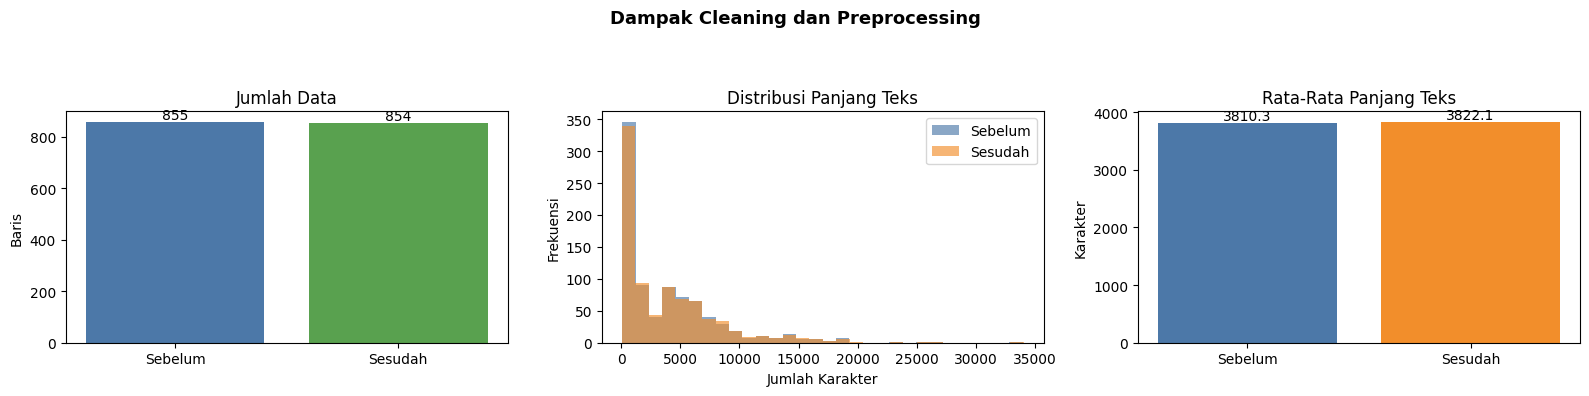

In [4]:
preprocessing_service = PreprocessingService()

clean_df = text_df.filter(
    pl.col(config.COL_TEXT).is_not_null()
    & (pl.col(config.COL_TEXT).str.strip_chars().str.len_chars() > 0)
)

clean_df = dataset_service.deduplicate(clean_df)

processed_df = preprocessing_service.process_dataframe(clean_df).filter(
    pl.col(config.COL_PROCESSED).is_not_null()
    & (pl.col(config.COL_PROCESSED).str.strip_chars().str.len_chars() > 0)
)

processed_summary = dataset_service.build_summary(processed_df)

artifact_service.save_dataframe(
    processed_df,
    OUTPUT_DATASET_PATH,
)
dataset_service.export_summary(
    processed_summary,
    OUTPUT_SUMMARY_PATH,
)

print(f"Baris setelah preprocessing: {processed_df.height:,}")

display(
    processed_df.select(
        config.COL_ID,
        config.COL_TEXT,
        config.COL_PROCESSED,
    ).head(20)
)

fig_preprocessing = visualization_service.plot_preprocessing_overview(
    text_df,
    processed_df,
)

## 4. Rule-Based Sentiment


id,processed_text,rule_label,rule_score,rule_confidence,rule_hits
"""1""","""program listrik desa di papua …","""positif""",2.1875,0.7292,"""terang, terang, terang, terang"""
"""2""","""ari yunianto on instagram beka…","""netral""",0.0,0.0,""""""
"""3""","""ois power on instagram pembang…","""netral""",0.0,0.0,""""""
"""4""","""teknik listrik on instagram pa…","""netral""",0.0,0.0,""""""
"""5""","""datascrip service center on in…","""netral""",0.0,0.0,""""""
"""6""","""tiktok - make your day listrik…","""netral""",0.0,0.0,""""""
"""7""","""damai cable indonesia on insta…","""positif""",2.25,0.75,"""awet, awet"""
"""8""","""tiktok - make your day teknolo…","""netral""",0.0,0.0,""""""
"""9""","""wujud negara hadir, pemerintah…","""positif""",4.975,1.0,"""hemat, terang, terang, baik"""
"""10""","""warga pulau lemukutan harapkan…","""netral""",0.0,0.0,""""""


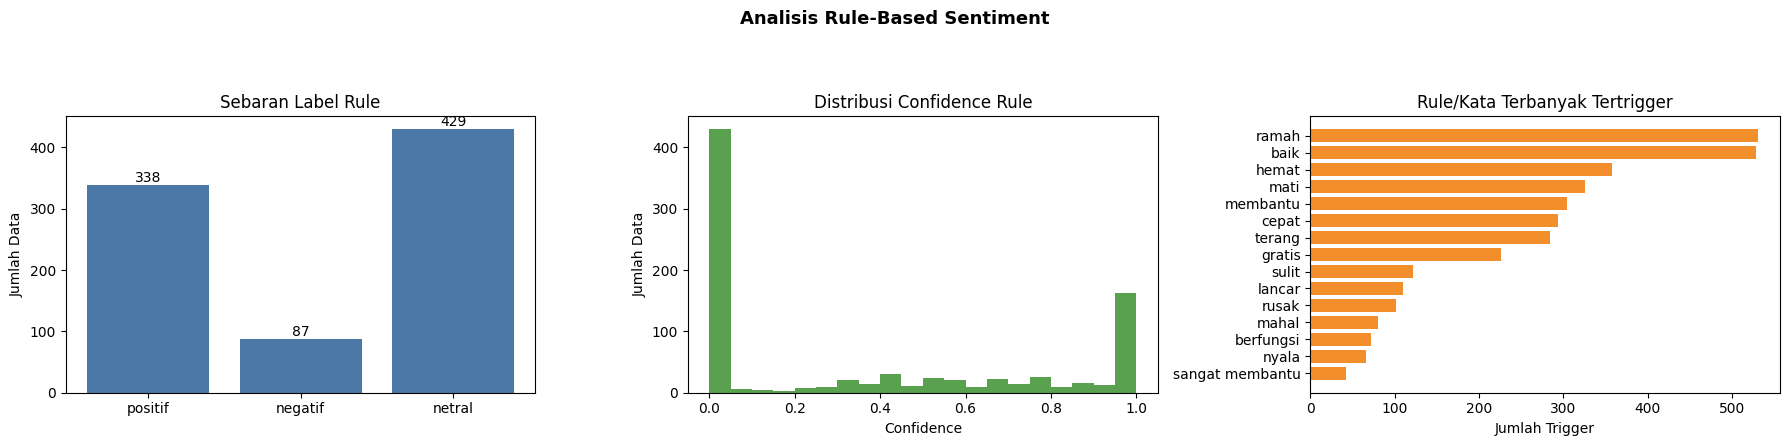

In [5]:
lexicon_service = LexiconSentimentService()
rule_df = lexicon_service.analyze_dataframe(processed_df)

rule_preview = rule_df.select(
    config.COL_ID,
    config.COL_PROCESSED,
    config.COL_RULE_LABEL,
    "rule_score",
    config.COL_RULE_CONFIDENCE,
    "rule_hits",
)
display(rule_preview.head(25))
fig_rule = visualization_service.plot_rule_sentiment_overview(rule_df)


## 5. Embedding dan Clustering Semantic


id,rule_label,cluster_id,cluster_size,semantic_label,semantic_similarity
"""1""","""positif""",-1,664,"""netral""",0.0
"""2""","""netral""",-1,664,"""netral""",0.0
"""3""","""netral""",-1,664,"""netral""",0.0
"""4""","""netral""",-1,664,"""netral""",0.0
"""5""","""netral""",-1,664,"""netral""",0.0
"""6""","""netral""",-1,664,"""netral""",0.0
"""7""","""positif""",-1,664,"""netral""",0.0
"""8""","""netral""",-1,664,"""netral""",0.0
"""9""","""positif""",-1,664,"""netral""",0.0
"""10""","""netral""",-1,664,"""netral""",0.0


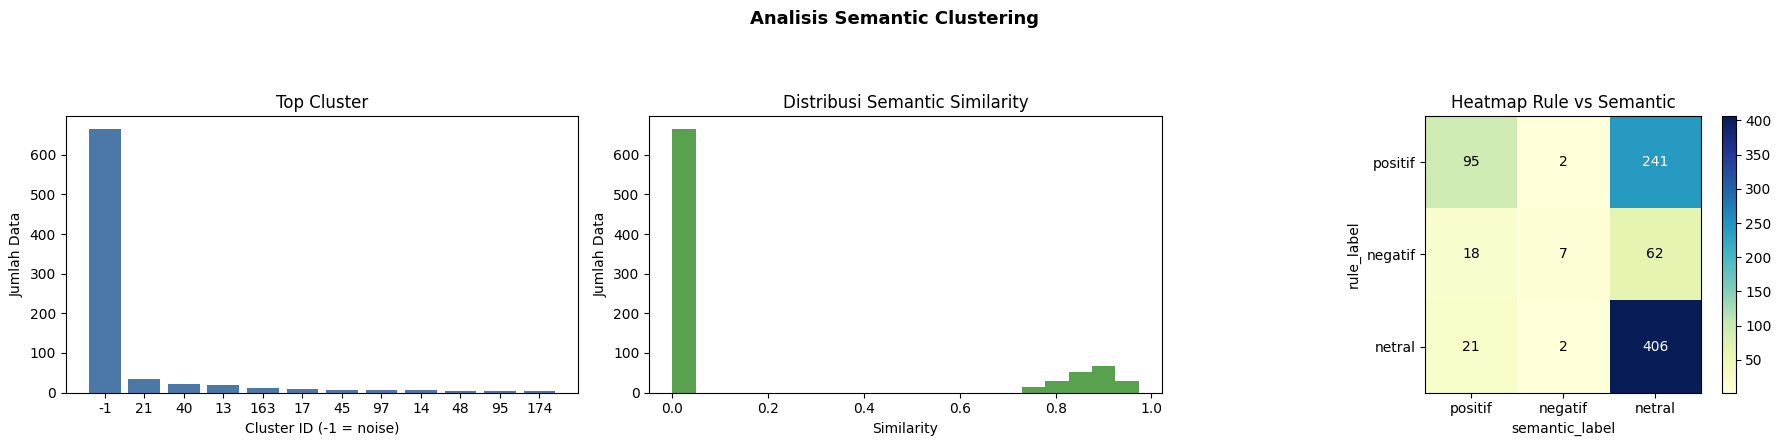

In [6]:
embedding_service = EmbeddingService(backend="hashing")
clustering_service = ClusteringService()

embedded_df, vectors = embedding_service.transform_dataframe(rule_df)
clustered_df = clustering_service.cluster_dataframe(embedded_df, vectors)

cluster_preview = clustered_df.select(
    config.COL_ID,
    config.COL_RULE_LABEL,
    config.COL_CLUSTER_ID,
    "cluster_size",
    config.COL_SEMANTIC_LABEL,
    config.COL_SEMANTIC_SIMILARITY,
)
display(cluster_preview.head(25))
fig_semantic = visualization_service.plot_semantic_overview(clustered_df)


## 6. Ambiguity Detection Tanpa LLM


id,rule_label,semantic_label,final_label,is_ambiguous,ambiguity_reason,decision_source
"""1""","""positif""","""netral""","""positif""",true,"""low_semantic_similarity, clust…","""non_llm_ambiguous"""
"""2""","""netral""","""netral""","""netral""",true,"""low_rule_confidence, low_seman…","""non_llm_ambiguous"""
"""3""","""netral""","""netral""","""netral""",true,"""low_rule_confidence, low_seman…","""non_llm_ambiguous"""
"""4""","""netral""","""netral""","""netral""",true,"""low_rule_confidence, low_seman…","""non_llm_ambiguous"""
"""5""","""netral""","""netral""","""netral""",true,"""low_rule_confidence, low_seman…","""non_llm_ambiguous"""
"""6""","""netral""","""netral""","""netral""",true,"""low_rule_confidence, low_seman…","""non_llm_ambiguous"""
"""7""","""positif""","""netral""","""positif""",true,"""low_semantic_similarity, clust…","""non_llm_ambiguous"""
"""8""","""netral""","""netral""","""netral""",true,"""low_rule_confidence, low_seman…","""non_llm_ambiguous"""
"""9""","""positif""","""netral""","""positif""",true,"""low_semantic_similarity, clust…","""non_llm_ambiguous"""
"""10""","""netral""","""netral""","""netral""",true,"""low_rule_confidence, low_seman…","""non_llm_ambiguous"""


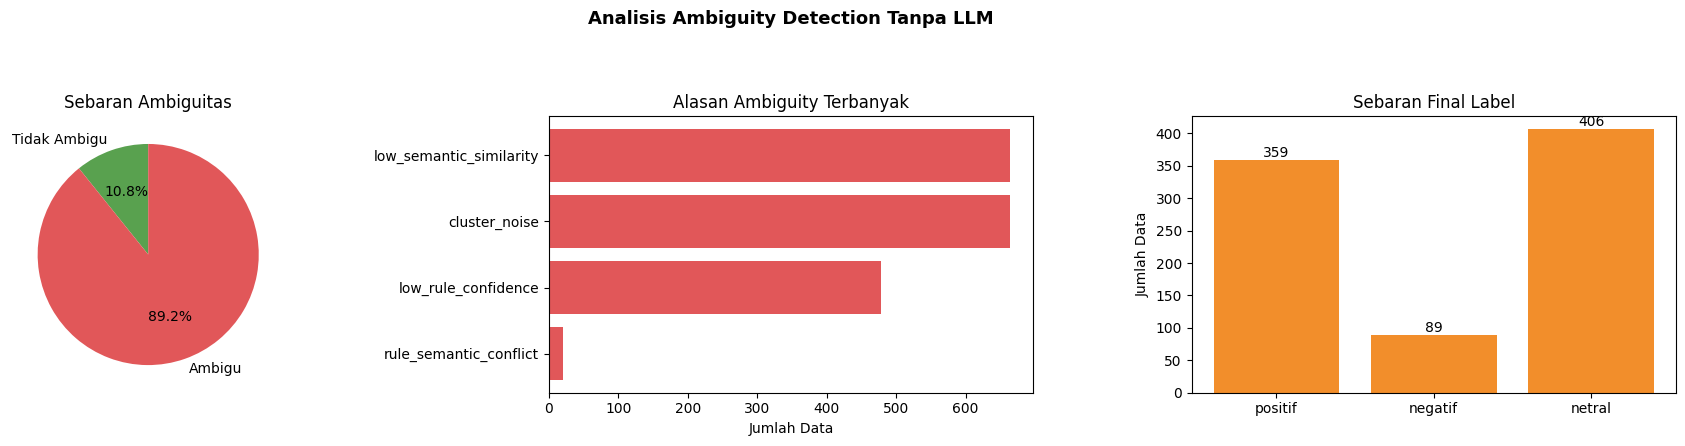

In [7]:
ambiguity_service = AmbiguityService()
final_df = ambiguity_service.decide_dataframe(clustered_df)

ambiguity_columns = [
    config.COL_ID,
    config.COL_RULE_LABEL,
    config.COL_SEMANTIC_LABEL,
    config.COL_FINAL_LABEL,
    config.COL_IS_AMBIGUOUS,
    "ambiguity_reason",
    "decision_source",
]
if config.COL_ACTUAL_LABEL in final_df.columns:
    ambiguity_columns.insert(1, config.COL_ACTUAL_LABEL)

ambiguity_preview = final_df.select(ambiguity_columns)
display(ambiguity_preview.head(25))
fig_ambiguity = visualization_service.plot_ambiguity_overview(final_df)


## 7. Evaluasi Skenario Tanpa LLM


In [8]:
artifact_service.save_dataframe(final_df, OUTPUT_RESULTS_PATH)

if config.COL_ACTUAL_LABEL in final_df.columns:
    metrics = evaluation_service.evaluate_dataframe(final_df)
    artifact_service.save_json(metrics, OUTPUT_METRICS_PATH)

    print(f"Hasil disimpan: {OUTPUT_RESULTS_PATH}")
    print(f"Metrik disimpan: {OUTPUT_METRICS_PATH}")
    display(metrics)
    fig_evaluation = visualization_service.plot_evaluation_dashboard(final_df, metrics)
else:
    metrics = {
        "total": final_df.height,
        "predicted_distribution": (
            final_df.group_by(config.COL_FINAL_LABEL)
            .agg(pl.len().alias("count"))
            .sort(config.COL_FINAL_LABEL)
            .to_dicts()
        ),
        "note": f"Evaluasi metrik dilewati karena kolom {config.COL_ACTUAL_LABEL!r} tidak tersedia.",
    }
    artifact_service.save_json(metrics, OUTPUT_METRICS_PATH)

    print(f"Hasil disimpan: {OUTPUT_RESULTS_PATH}")
    print(f"Ringkasan prediksi disimpan: {OUTPUT_METRICS_PATH}")
    display(metrics)


Hasil disimpan: E:\School\tugas-akhir\project\outputs\results\scenario_without_llm.csv
Ringkasan prediksi disimpan: E:\School\tugas-akhir\project\outputs\artifacts\scenario_without_llm_metrics.json


{'total': 854,
 'predicted_distribution': [{'final_label': 'negatif', 'count': 89},
  {'final_label': 'netral', 'count': 406},
  {'final_label': 'positif', 'count': 359}],
 'note': "Evaluasi metrik dilewati karena kolom 'actual_label' tidak tersedia."}

## 8. Visualisasi Evaluasi Detail


In [9]:
if config.COL_ACTUAL_LABEL in final_df.columns:
    fig_evaluation_detail = visualization_service.plot_evaluation_dashboard(final_df, metrics)
    fig_evaluation_detail
else:
    final_df.group_by(
        config.COL_FINAL_LABEL,
        config.COL_IS_AMBIGUOUS,
    ).agg(pl.len().alias("count")).sort(
        config.COL_FINAL_LABEL,
        config.COL_IS_AMBIGUOUS,
    )


## 9. Ringkasan Distribusi


In [10]:
summary_columns = [
    config.COL_FINAL_LABEL,
    config.COL_IS_AMBIGUOUS,
]
if config.COL_ACTUAL_LABEL in final_df.columns:
    summary_columns.insert(0, config.COL_ACTUAL_LABEL)

final_df.group_by(summary_columns).agg(pl.len().alias("count")).sort(summary_columns)


final_label,is_ambiguous,count
"""negatif""",false,7
"""negatif""",true,82
"""netral""",true,406
"""positif""",false,85
"""positif""",true,274
